# ☕ Afficionado Coffee Roasters
## Sales Trend & Time-Based Performance Analysis — 2025

---
**Dataset:** 149,116 transactions · 3 store locations · FY 2025  
**Objective:** Identify temporal demand patterns to support staffing, operations, and revenue optimization  

### 📋 Table of Contents
1. [Environment Setup & Imports](#1)
2. [Data Loading & Validation](#2)
3. [Feature Engineering](#3)
4. [Exploratory Data Analysis — Overview](#4)
5. [Hourly Demand Analysis](#5)
6. [Time Bucket Analysis](#6)
7. [Store-Level Comparison](#7)
8. [Product Category Analysis](#8)
9. [Cross-Location Heatmap](#9)
10. [Key Insights & Recommendations](#10)

---
## 1. Environment Setup & Imports <a id='1'></a>

In [1]:
# Install required libraries (run once if not already installed)
# !pip install pandas matplotlib seaborn plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Global plot style ─────────────────────────────────────────────────────────
BROWN       = '#6F4E37'
LIGHT_BROWN = '#C8A97E'
DARK_BROWN  = '#3D2314'
CREAM       = '#FAF7F2'
STORE_COLORS = {
    "Hell's Kitchen":  '#6F4E37',
    'Astoria':         '#C8A97E',
    'Lower Manhattan': '#A0522D',
}

plt.rcParams.update({
    'figure.facecolor':  CREAM,
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#CCCCCC',
    'axes.labelcolor':   DARK_BROWN,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   DARK_BROWN,
    'xtick.color':       '#555555',
    'ytick.color':       '#555555',
    'font.family':       'sans-serif',
    'grid.color':        '#EEEEEE',
    'grid.linestyle':    '--',
    'grid.alpha':        0.7,
})

print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


---
## 2. Data Loading & Validation <a id='2'></a>

In [3]:
# ── Load dataset ──────────────────────────────────────────────────────────────
DATA_PATH = 'Afficionado_Coffee_Roasters_xlsx_-_Transactions.csv'

df_raw = pd.read_csv("C:/Users/heramb/OneDrive/Desktop/Sales Trend and Time-Based Performance Analysis for Afficionado Coffee Roasters/data/Transactions.csv")

print(f'✅ Dataset loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head()

✅ Dataset loaded: 149,116 rows × 11 columns


,transaction_id,year,transaction_time,transaction_qty,store_id,store_location,product_id,unit_price,product_category,product_type,product_detail
0,1,2025,7:06:11,2,5,Lower Manhattan,32,3.0,Coffee,Gourmet brewed coffee,Ethiopia Rg
1,2,2025,7:08:56,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg
2,3,2025,7:14:04,2,5,Lower Manhattan,59,4.5,Drinking Chocolate,Hot chocolate,Dark chocolate Lg
3,4,2025,7:20:24,1,5,Lower Manhattan,22,2.0,Coffee,Drip coffee,Our Old Time Diner Blend Sm
4,5,2025,7:22:41,2,5,Lower Manhattan,57,3.1,Tea,Brewed Chai tea,Spicy Eye Opener Chai Lg


In [4]:
# ── Column data types ─────────────────────────────────────────────────────────
df_raw.dtypes

transaction_id        int64
year                  int64
transaction_time     object
transaction_qty       int64
store_id              int64
store_location       object
product_id            int64
unit_price          float64
product_category     object
product_type         object
product_detail       object
dtype: object

In [5]:
# ── Missing value check ───────────────────────────────────────────────────────
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_report)
print(f'\n✅ Total missing values: {missing.sum()}')

                  Missing Count  Missing %
transaction_id                0        0.0
year                          0        0.0
transaction_time              0        0.0
transaction_qty               0        0.0
store_id                      0        0.0
store_location                0        0.0
product_id                    0        0.0
unit_price                    0        0.0
product_category              0        0.0
product_type                  0        0.0
product_detail                0        0.0

✅ Total missing values: 0


In [6]:
# ── Duplicate check ───────────────────────────────────────────────────────────
dupes = df_raw['transaction_id'].duplicated().sum()
print(f'Duplicate transaction IDs: {dupes}')

# ── Range validation ──────────────────────────────────────────────────────────
print(f'transaction_qty range : {df_raw["transaction_qty"].min()} – {df_raw["transaction_qty"].max()}')
print(f'unit_price range      : ${df_raw["unit_price"].min():.2f} – ${df_raw["unit_price"].max():.2f}')

# ── Store distribution ────────────────────────────────────────────────────────
print('\nTransactions per store:')
print(df_raw['store_location'].value_counts())

print('\n✅ All validation checks passed — dataset is clean.')

Duplicate transaction IDs: 0
transaction_qty range : 1 – 8
unit_price range      : $0.80 – $45.00

Transactions per store:
store_location
Hell's Kitchen     50735
Astoria            50599
Lower Manhattan    47782
Name: count, dtype: int64

✅ All validation checks passed — dataset is clean.


---
## 3. Feature Engineering <a id='3'></a>

In [7]:
df = df_raw.copy()

# Revenue
df['revenue'] = df['transaction_qty'] * df['unit_price']

# Hour — parse time-only string HH:MM:SS
df['hour'] = df['transaction_time'].str.split(':').str[0].astype(int)

# Time bucket
def assign_bucket(h):
    if   6 <= h <= 11: return 'Morning (6–11)'
    elif 12 <= h <= 16: return 'Afternoon (12–16)'
    elif 17 <= h <= 21: return 'Evening (17–21)'
    else:               return 'Late/Early (22–5)'

df['time_bucket'] = df['hour'].apply(assign_bucket)

BUCKET_ORDER = ['Morning (6–11)', 'Afternoon (12–16)', 'Evening (17–21)', 'Late/Early (22–5)']
df['time_bucket'] = pd.Categorical(df['time_bucket'], categories=BUCKET_ORDER, ordered=True)

# Sequential day number (proxy for date since no date column exists)
df = df.sort_values('transaction_id').reset_index(drop=True)
df['day_num']  = ((df.index / len(df)) * 182).astype(int) % 7
DAY_NAMES      = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['day_name'] = df['day_num'].map(lambda d: DAY_NAMES[d])

print('✅ Feature engineering complete.')
print(f'New columns added: revenue, hour, time_bucket, day_num, day_name')
df[['transaction_id','transaction_time','hour','time_bucket','revenue','day_name']].head(8)

✅ Feature engineering complete.
New columns added: revenue, hour, time_bucket, day_num, day_name


,transaction_id,transaction_time,hour,time_bucket,revenue,day_name
0,1,7:06:11,7,Morning (6–11),6.0,Monday
1,2,7:08:56,7,Morning (6–11),6.2,Monday
2,3,7:14:04,7,Morning (6–11),9.0,Monday
3,4,7:20:24,7,Morning (6–11),2.0,Monday
4,5,7:22:41,7,Morning (6–11),6.2,Monday
5,6,7:22:41,7,Morning (6–11),3.0,Monday
6,7,7:25:49,7,Morning (6–11),2.0,Monday
7,8,7:33:34,7,Morning (6–11),4.0,Monday


---
## 4. Exploratory Data Analysis — Overview <a id='4'></a>

In [8]:
# ── Overall summary statistics ────────────────────────────────────────────────
print('=' * 45)
print('        AFFICIONADO COFFEE — 2025 SUMMARY')
print('=' * 45)
print(f'  Total Revenue      : ${df["revenue"].sum():>12,.2f}')
print(f'  Total Transactions : {len(df):>12,}')
print(f'  Avg Transaction    : ${df["revenue"].mean():>12.2f}')
print(f'  Median Transaction : ${df["revenue"].median():>12.2f}')
print(f'  Max Transaction    : ${df["revenue"].max():>12.2f}')
print(f'  Min Transaction    : ${df["revenue"].min():>12.2f}')
print(f'  Unique Products    : {df["product_detail"].nunique():>12,}')
print(f'  Store Locations    : {df["store_location"].nunique():>12,}')
print('=' * 45)

        AFFICIONADO COFFEE — 2025 SUMMARY
  Total Revenue      : $  698,812.33
  Total Transactions :      149,116
  Avg Transaction    : $        4.69
  Median Transaction : $        3.75
  Max Transaction    : $      360.00
  Min Transaction    : $        0.80
  Unique Products    :           80
  Store Locations    :            3


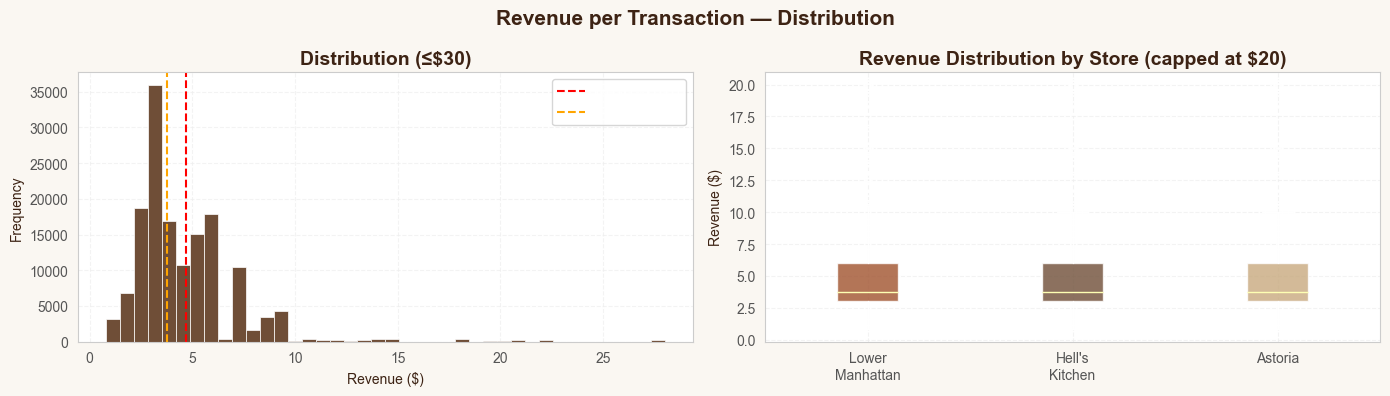

In [9]:
# ── Revenue distribution histogram ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Revenue per Transaction — Distribution', fontsize=15, fontweight='bold', color=DARK_BROWN)

# Histogram (exclude extreme outliers for clarity)
clip = df[df['revenue'] <= 30]['revenue']
axes[0].hist(clip, bins=40, color=BROWN, edgecolor='white', linewidth=0.5)
axes[0].set_title('Distribution (≤$30)')
axes[0].set_xlabel('Revenue ($)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['revenue'].mean(),   color='red',    linestyle='--', label=f'Mean ${df["revenue"].mean():.2f}')
axes[0].axvline(df['revenue'].median(), color='orange', linestyle='--', label=f'Median ${df["revenue"].median():.2f}')
axes[0].legend()
axes[0].grid(True)

# Box plot by store
stores = df['store_location'].unique()
data_box = [df[df['store_location'] == s]['revenue'].clip(upper=20) for s in stores]
bp = axes[1].boxplot(data_box, patch_artist=True, labels=[s.replace(" ", "\n") for s in stores])
colors_box = [STORE_COLORS[s] for s in stores]
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title('Revenue Distribution by Store (capped at $20)')
axes[1].set_ylabel('Revenue ($)')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [10]:
# ── Transactions per store ────────────────────────────────────────────────────
store_summary = df.groupby('store_location').agg(
    Total_Revenue   = ('revenue', 'sum'),
    Transactions    = ('transaction_id', 'count'),
    Avg_Transaction = ('revenue', 'mean'),
).round(2)
store_summary['Revenue_Share_%'] = (store_summary['Total_Revenue'] / store_summary['Total_Revenue'].sum() * 100).round(1)

display(store_summary.style
    .format({'Total_Revenue': '${:,.2f}', 'Avg_Transaction': '${:.2f}', 'Revenue_Share_%': '{:.1f}%', 'Transactions': '{:,}'})
    .background_gradient(subset=['Total_Revenue'], cmap='YlOrBr')
    .set_caption('Store Performance Summary'))

,Total_Revenue,Transactions,Avg_Transaction,Revenue_Share_%
store_location,,,,
Astoria,"$232,243.91","50,599",$4.59,33.2%
Hell's Kitchen,"$236,511.17","50,735",$4.66,33.8%
Lower Manhattan,"$230,057.25","47,782",$4.81,32.9%


---
## 5. Hourly Demand Analysis <a id='5'></a>

In [11]:
# ── Aggregate by hour ─────────────────────────────────────────────────────────
hourly = df.groupby('hour').agg(
    Revenue      = ('revenue', 'sum'),
    Transactions = ('transaction_id', 'count'),
    Avg_Rev      = ('revenue', 'mean'),
).reset_index()

hourly['Rev_Share_%'] = (hourly['Revenue'] / hourly['Revenue'].sum() * 100).round(1)
hourly['hour_label']  = hourly['hour'].apply(lambda h: f"{h}:00")

display(hourly[['hour_label','Revenue','Transactions','Avg_Rev','Rev_Share_%']]
    .rename(columns={'hour_label':'Hour','Avg_Rev':'Avg/Txn ($)','Rev_Share_%':'Share %'})
    .style
    .format({'Revenue': '${:,.0f}', 'Transactions': '{:,}', 'Avg/Txn ($)': '${:.2f}', 'Share %': '{:.1f}%'})
    .background_gradient(subset=['Revenue'], cmap='YlOrBr')
    .set_caption('Hourly Revenue & Transaction Breakdown'))

,Hour,Revenue,Transactions,Avg/Txn ($),Share %
0,6:00,"$21,900","4,594",$4.77,3.1%
1,7:00,"$63,526","13,428",$4.73,9.1%
2,8:00,"$82,700","17,654",$4.68,11.8%
3,9:00,"$85,170","17,764",$4.79,12.2%
4,10:00,"$88,673","18,545",$4.78,12.7%
5,11:00,"$46,319","9,766",$4.74,6.6%
6,12:00,"$40,193","8,708",$4.62,5.8%
7,13:00,"$40,367","8,714",$4.63,5.8%
8,14:00,"$41,305","8,933",$4.62,5.9%
9,15:00,"$41,733","8,979",$4.65,6.0%


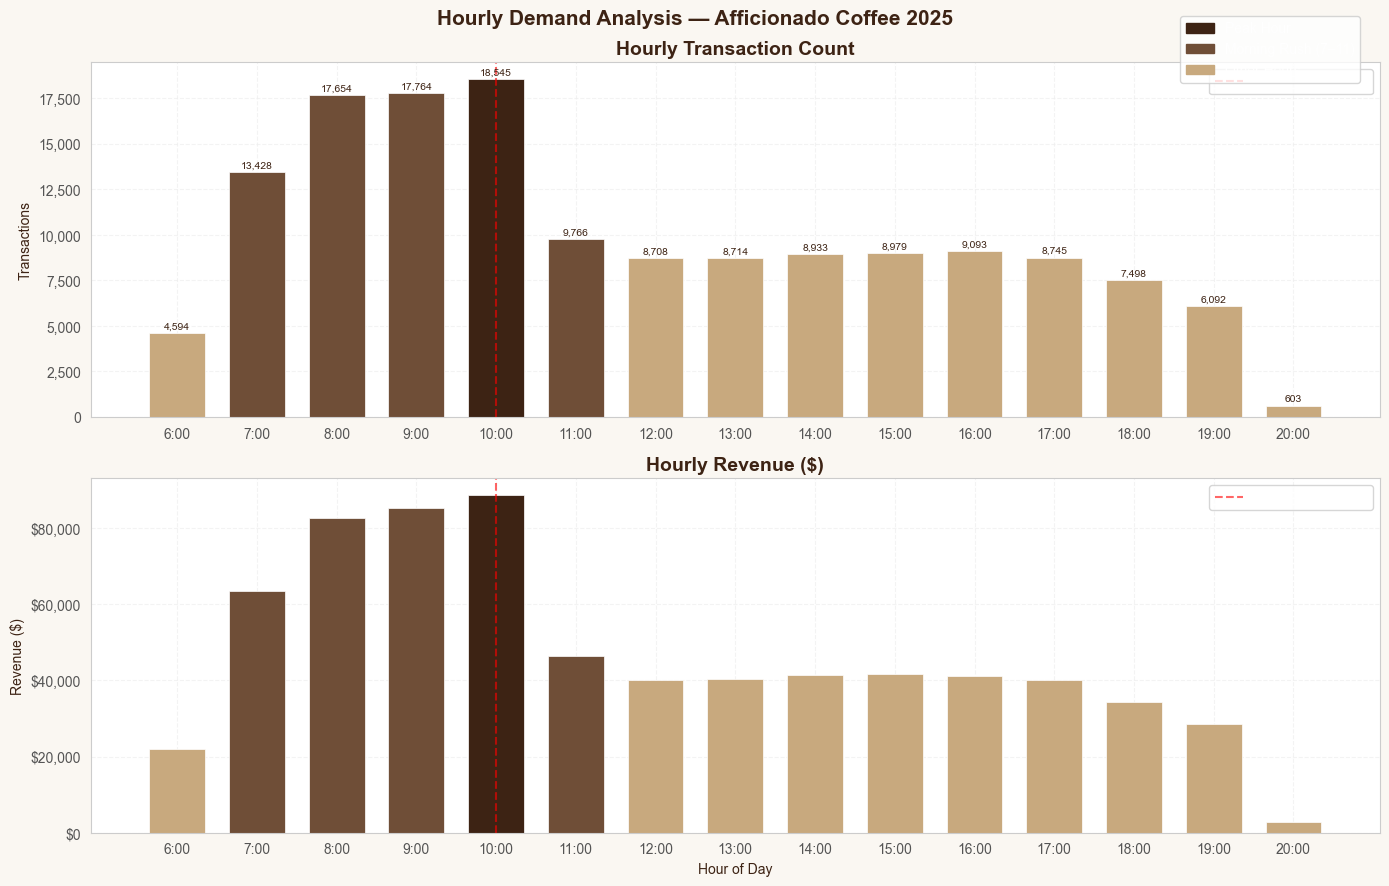


📌 Peak Hour: 10:00 AM with 18,545 transactions and $88,673 revenue


In [12]:
# ── Hourly transactions bar chart ────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.suptitle('Hourly Demand Analysis — Afficionado Coffee 2025', fontsize=15, fontweight='bold', color=DARK_BROWN)

peak_hour = hourly.loc[hourly['Transactions'].idxmax(), 'hour']
bar_colors = [DARK_BROWN if h == peak_hour else (BROWN if h >= 7 and h <= 11 else LIGHT_BROWN)
              for h in hourly['hour']]

# Transactions
bars = axes[0].bar(hourly['hour_label'], hourly['Transactions'],
                   color=bar_colors, edgecolor='white', linewidth=0.5, width=0.7)
axes[0].set_title('Hourly Transaction Count')
axes[0].set_ylabel('Transactions')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[0].axvline(x=list(hourly['hour_label']).index('10:00'), color='red',
                linestyle='--', alpha=0.6, label='Peak Hour (10:00)')
axes[0].legend()
axes[0].grid(True, axis='y')
for bar, val in zip(bars, hourly['Transactions']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
                 f'{val:,}', ha='center', va='bottom', fontsize=7.5, color=DARK_BROWN)

# Revenue
axes[1].bar(hourly['hour_label'], hourly['Revenue'],
            color=bar_colors, edgecolor='white', linewidth=0.5, width=0.7)
axes[1].set_title('Hourly Revenue ($)')
axes[1].set_ylabel('Revenue ($)')
axes[1].set_xlabel('Hour of Day')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].axvline(x=list(hourly['hour_label']).index('10:00'), color='red',
                linestyle='--', alpha=0.6, label='Peak Hour (10:00)')
axes[1].legend()
axes[1].grid(True, axis='y')

# Legend patch
from matplotlib.patches import Patch
legend_patches = [
    Patch(color=DARK_BROWN, label='Peak Hour'),
    Patch(color=BROWN,      label='Morning Rush (7–11)'),
    Patch(color=LIGHT_BROWN, label='Other Hours'),
]
fig.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(0.98, 0.98))

plt.tight_layout()
plt.show()

print(f'\n📌 Peak Hour: 10:00 AM with 18,545 transactions and $88,673 revenue')

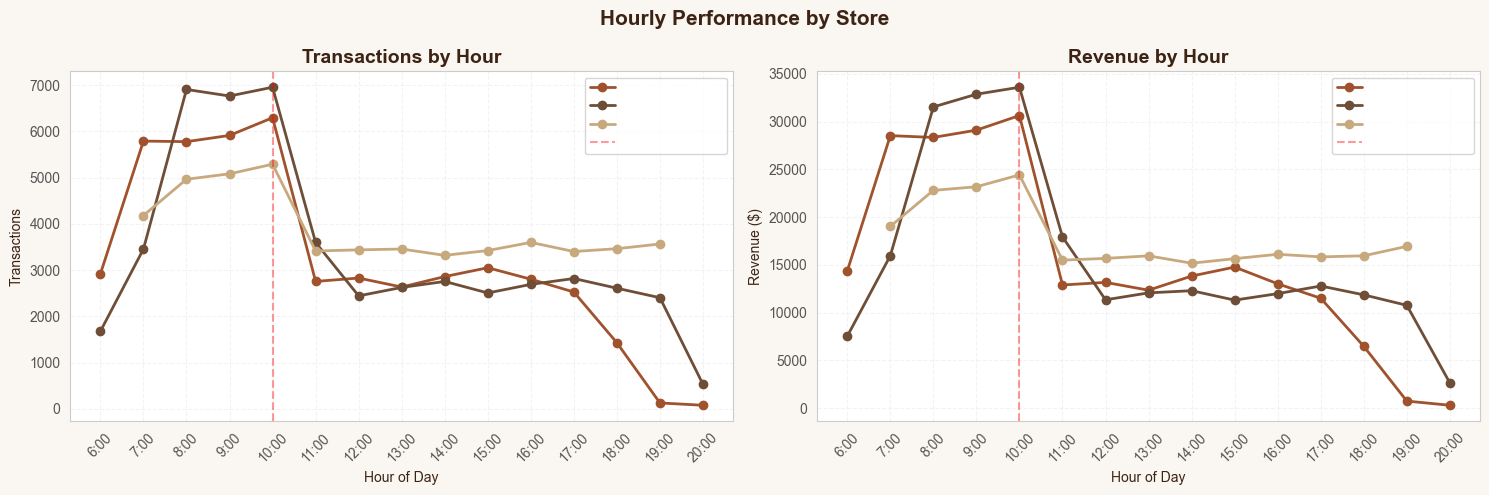

In [13]:
# ── Hourly trend line by store ────────────────────────────────────────────────
hourly_store = df.groupby(['store_location', 'hour']).agg(
    Revenue=('revenue','sum'),
    Transactions=('transaction_id','count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Hourly Performance by Store', fontsize=15, fontweight='bold', color=DARK_BROWN)

for store in df['store_location'].unique():
    sub = hourly_store[hourly_store['store_location'] == store]
    axes[0].plot(sub['hour'], sub['Transactions'], marker='o', linewidth=2,
                 color=STORE_COLORS[store], label=store)
    axes[1].plot(sub['hour'], sub['Revenue'], marker='o', linewidth=2,
                 color=STORE_COLORS[store], label=store)

for ax, title, ylabel in zip(axes,
    ['Transactions by Hour', 'Revenue by Hour'],
    ['Transactions', 'Revenue ($)']):
    ax.set_title(title)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(6, 21))
    ax.set_xticklabels([f'{h}:00' for h in range(6, 21)], rotation=45)
    ax.axvline(x=10, color='red', linestyle='--', alpha=0.4, label='Peak (10:00)')
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
plt.show()

---
## 6. Time Bucket Analysis <a id='6'></a>

In [14]:
# ── Time bucket summary ───────────────────────────────────────────────────────
bucket_agg = df.groupby('time_bucket', observed=True).agg(
    Revenue      = ('revenue', 'sum'),
    Transactions = ('transaction_id', 'count'),
    Avg_Rev      = ('revenue', 'mean'),
).reset_index()

bucket_agg['Rev_Share_%'] = (bucket_agg['Revenue'] / bucket_agg['Revenue'].sum() * 100).round(1)
bucket_agg['Txn_Share_%'] = (bucket_agg['Transactions'] / bucket_agg['Transactions'].sum() * 100).round(1)

display(bucket_agg.style
    .format({'Revenue': '${:,.0f}', 'Avg_Rev': '${:.2f}', 'Rev_Share_%': '{:.1f}%',
             'Txn_Share_%': '{:.1f}%', 'Transactions': '{:,}'})
    .background_gradient(subset=['Revenue'], cmap='YlOrBr')
    .set_caption('Revenue & Transactions by Time Bucket'))

,time_bucket,Revenue,Transactions,Avg_Rev,Rev_Share_%,Txn_Share_%
0,Morning (6–11),"$388,289","81,751",$4.75,55.6%,54.8%
1,Afternoon (12–16),"$204,721","44,427",$4.61,29.3%,29.8%
2,Evening (17–21),"$105,803","22,938",$4.61,15.1%,15.4%


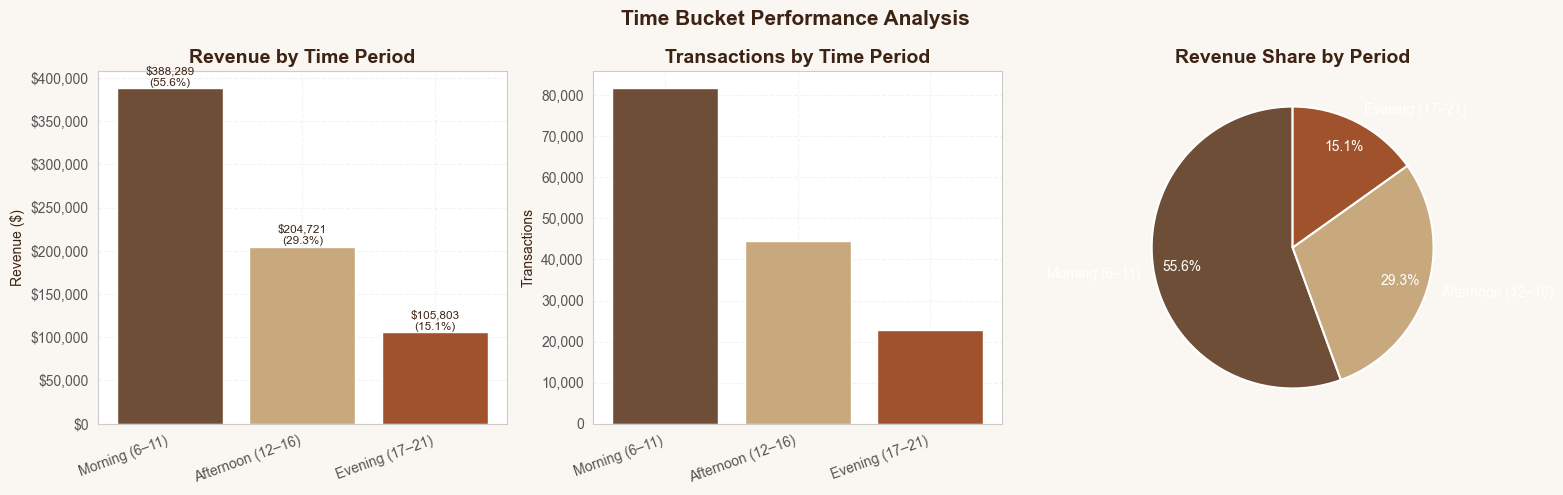


📌 Morning (6–11 AM) contributes 55.6% of total revenue across all stores.


In [15]:
# ── Time bucket charts ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Time Bucket Performance Analysis', fontsize=15, fontweight='bold', color=DARK_BROWN)

bucket_colors = [BROWN, LIGHT_BROWN, '#A0522D', '#D2B48C']

# Revenue bar
axes[0].bar(bucket_agg['time_bucket'], bucket_agg['Revenue'],
            color=bucket_colors[:len(bucket_agg)], edgecolor='white')
axes[0].set_title('Revenue by Time Period')
axes[0].set_ylabel('Revenue ($)')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (val, pct) in enumerate(zip(bucket_agg['Revenue'], bucket_agg['Rev_Share_%'])):
    axes[0].text(i, val + 3000, f'${val:,.0f}\n({pct}%)', ha='center', fontsize=8.5, color=DARK_BROWN)
axes[0].set_xticklabels(bucket_agg['time_bucket'], rotation=20, ha='right')
axes[0].grid(True, axis='y')

# Transactions bar
axes[1].bar(bucket_agg['time_bucket'], bucket_agg['Transactions'],
            color=bucket_colors[:len(bucket_agg)], edgecolor='white')
axes[1].set_title('Transactions by Time Period')
axes[1].set_ylabel('Transactions')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].set_xticklabels(bucket_agg['time_bucket'], rotation=20, ha='right')
axes[1].grid(True, axis='y')

# Revenue pie
wedge_colors = bucket_colors[:len(bucket_agg)]
axes[2].pie(bucket_agg['Revenue'], labels=bucket_agg['time_bucket'],
            autopct='%1.1f%%', colors=wedge_colors,
            startangle=90, pctdistance=0.8,
            wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[2].set_title('Revenue Share by Period')

plt.tight_layout()
plt.show()

morning_pct = bucket_agg[bucket_agg['time_bucket']=='Morning (6–11)']['Rev_Share_%'].values[0]
print(f'\n📌 Morning (6–11 AM) contributes {morning_pct}% of total revenue across all stores.')

---
## 7. Store-Level Comparison <a id='7'></a>

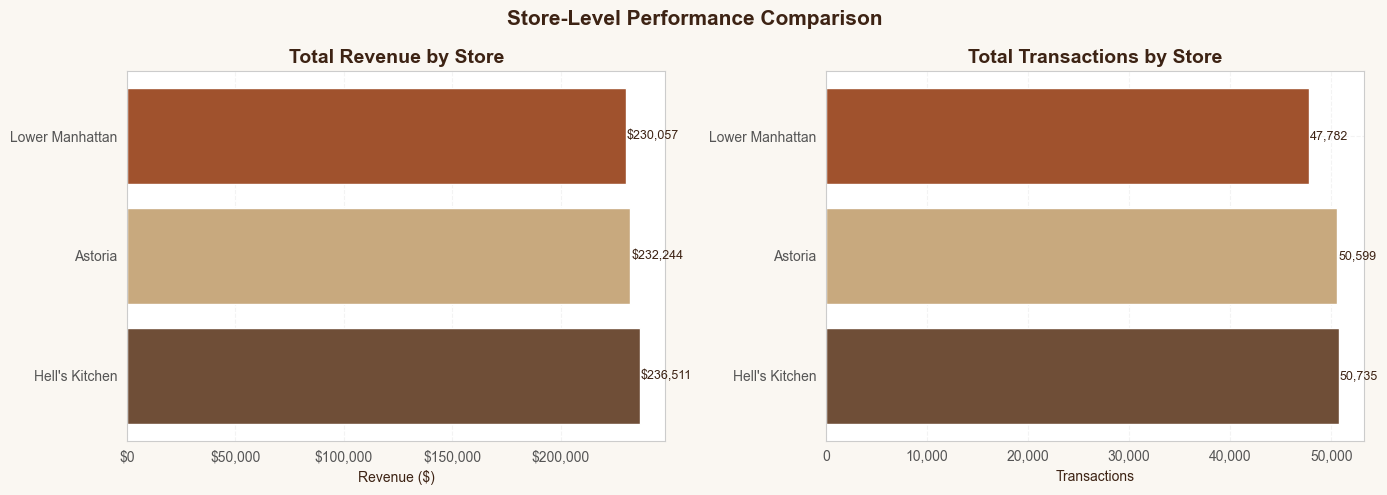

In [16]:
# ── Revenue comparison bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Store-Level Performance Comparison', fontsize=15, fontweight='bold', color=DARK_BROWN)

store_rev = df.groupby('store_location')['revenue'].sum().sort_values(ascending=False)
store_txn = df.groupby('store_location')['transaction_id'].count().sort_values(ascending=False)

store_color_list = [STORE_COLORS[s] for s in store_rev.index]

axes[0].barh(store_rev.index, store_rev.values, color=store_color_list, edgecolor='white')
axes[0].set_title('Total Revenue by Store')
axes[0].set_xlabel('Revenue ($)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, val in enumerate(store_rev.values):
    axes[0].text(val + 500, i, f'${val:,.0f}', va='center', fontsize=9, color=DARK_BROWN)
axes[0].grid(True, axis='x')

axes[1].barh(store_txn.index, store_txn.values,
             color=[STORE_COLORS[s] for s in store_txn.index], edgecolor='white')
axes[1].set_title('Total Transactions by Store')
axes[1].set_xlabel('Transactions')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:,.0f}'))
for i, val in enumerate(store_txn.values):
    axes[1].text(val + 100, i, f'{val:,}', va='center', fontsize=9, color=DARK_BROWN)
axes[1].grid(True, axis='x')

plt.tight_layout()
plt.show()

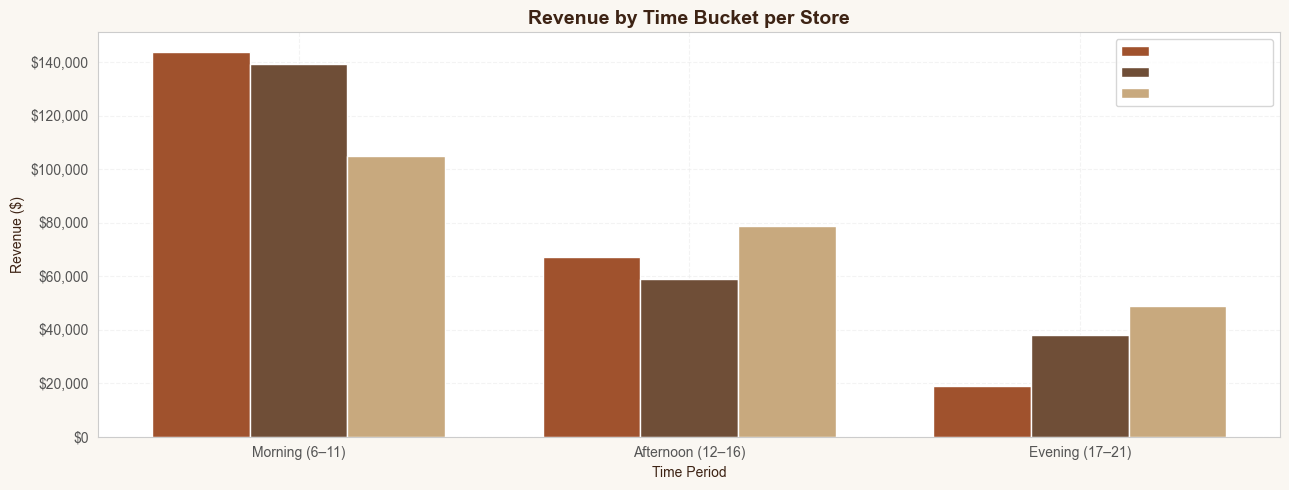

In [17]:
# ── Time bucket performance per store ─────────────────────────────────────────
bucket_store = df.groupby(['store_location','time_bucket'], observed=True)['revenue'].sum().reset_index()
stores = df['store_location'].unique()

bucket_pivot = bucket_store.pivot(index='time_bucket', columns='store_location', values='revenue').fillna(0)
bucket_pivot = bucket_pivot.reindex(BUCKET_ORDER[:3])  # exclude late/early

x     = np.arange(len(bucket_pivot))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 5))

for i, store in enumerate(stores):
    if store in bucket_pivot.columns:
        ax.bar(x + i*width, bucket_pivot[store], width, label=store,
               color=STORE_COLORS[store], edgecolor='white')

ax.set_title('Revenue by Time Bucket per Store', fontsize=14, fontweight='bold', color=DARK_BROWN)
ax.set_xlabel('Time Period')
ax.set_ylabel('Revenue ($)')
ax.set_xticks(x + width)
ax.set_xticklabels(bucket_pivot.index)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:,.0f}'))
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

---
## 8. Product Category Analysis <a id='8'></a>

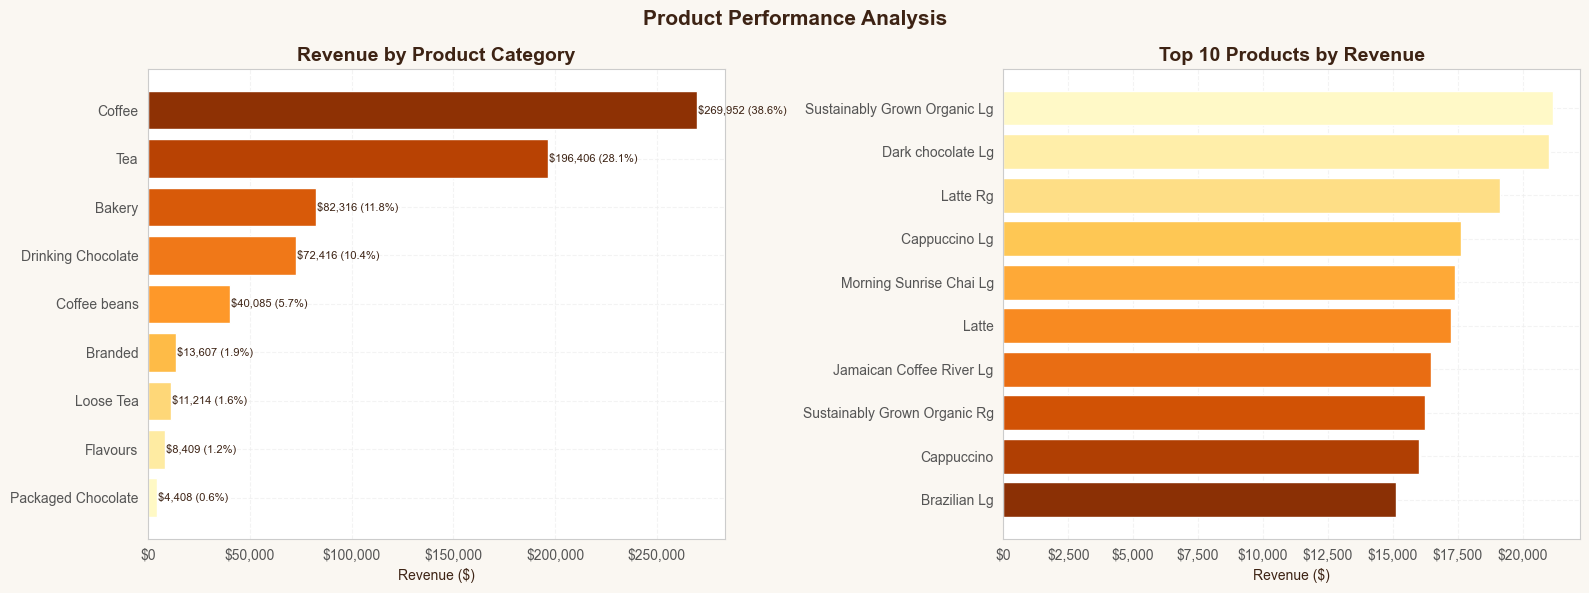

In [18]:
# ── Revenue by category ───────────────────────────────────────────────────────
cat_rev = df.groupby('product_category')['revenue'].sum().sort_values(ascending=False)
top10   = df.groupby('product_detail')['revenue'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Product Performance Analysis', fontsize=15, fontweight='bold', color=DARK_BROWN)

# Category horizontal bar
cat_colors = sns.color_palette('YlOrBr', len(cat_rev))[::-1]
axes[0].barh(cat_rev.index[::-1], cat_rev.values[::-1], color=cat_colors[::-1], edgecolor='white')
axes[0].set_title('Revenue by Product Category')
axes[0].set_xlabel('Revenue ($)')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, (idx, val) in enumerate(zip(cat_rev.index[::-1], cat_rev.values[::-1])):
    pct = val / cat_rev.sum() * 100
    axes[0].text(val + 500, i, f'${val:,.0f} ({pct:.1f}%)', va='center', fontsize=8, color=DARK_BROWN)
axes[0].grid(True, axis='x')

# Top 10 products
top_colors = sns.color_palette('YlOrBr', 10)[::-1]
axes[1].barh(top10.index[::-1], top10.values[::-1], color=top_colors, edgecolor='white')
axes[1].set_title('Top 10 Products by Revenue')
axes[1].set_xlabel('Revenue ($)')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].grid(True, axis='x')

plt.tight_layout()
plt.show()

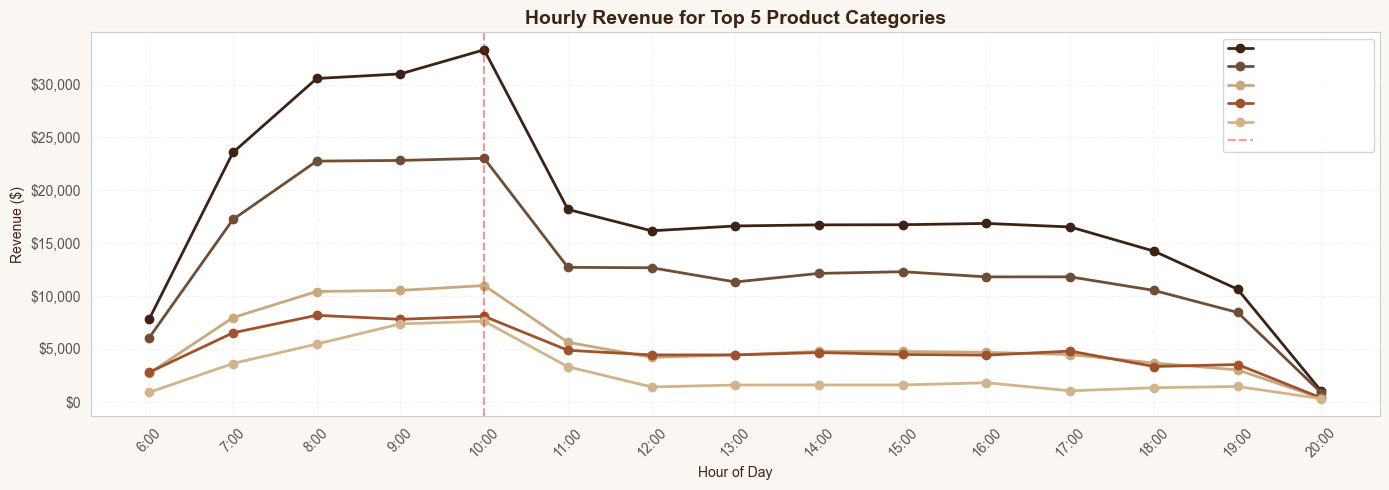

In [19]:
# ── Category demand by hour ───────────────────────────────────────────────────
top_cats = cat_rev.head(5).index.tolist()
cat_hour = df[df['product_category'].isin(top_cats)].groupby(
    ['hour','product_category'])['revenue'].sum().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
cat_line_colors = [DARK_BROWN, BROWN, LIGHT_BROWN, '#A0522D', '#D2B48C']

for i, cat in enumerate(top_cats):
    sub = cat_hour[cat_hour['product_category'] == cat]
    ax.plot(sub['hour'], sub['revenue'], marker='o', linewidth=2,
            label=cat, color=cat_line_colors[i])

ax.set_title('Hourly Revenue for Top 5 Product Categories', fontsize=14, fontweight='bold', color=DARK_BROWN)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Revenue ($)')
ax.set_xticks(range(6, 21))
ax.set_xticklabels([f'{h}:00' for h in range(6, 21)], rotation=45)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.axvline(x=10, color='red', linestyle='--', alpha=0.4, label='Peak Hour')
ax.legend(fontsize=9)
ax.grid(True)
plt.tight_layout()
plt.show()

---
## 9. Cross-Location Heatmap <a id='9'></a>

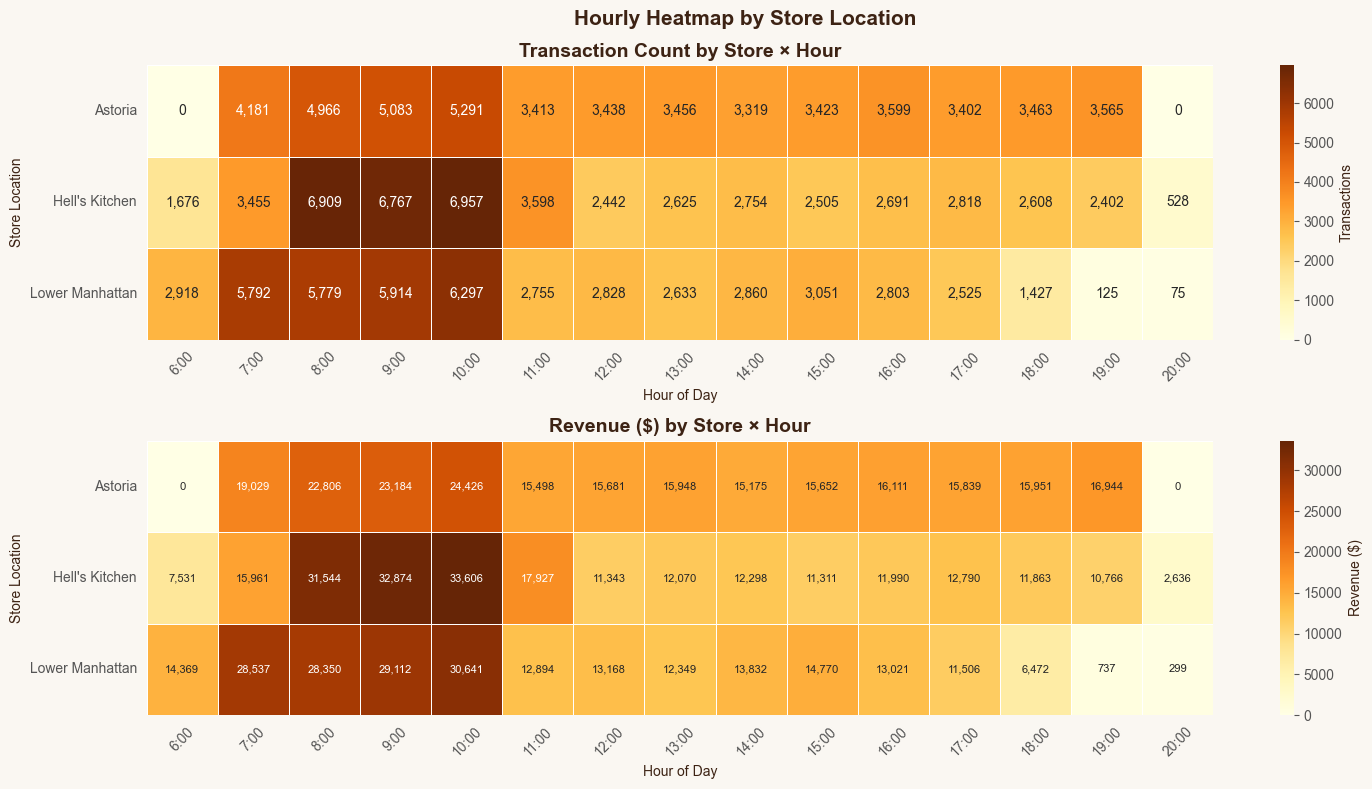

In [20]:
# ── Heatmap: Transactions by Store × Hour ─────────────────────────────────────
heat_txn = df.groupby(['store_location','hour'])['transaction_id'].count().unstack(fill_value=0)
heat_rev = df.groupby(['store_location','hour'])['revenue'].sum().unstack(fill_value=0)

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
fig.suptitle('Hourly Heatmap by Store Location', fontsize=15, fontweight='bold', color=DARK_BROWN)

sns.heatmap(heat_txn, ax=axes[0], cmap='YlOrBr', fmt=',d', annot=True,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Transactions'})
axes[0].set_title('Transaction Count by Store × Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Store Location')
axes[0].set_xticklabels([f'{h}:00' for h in heat_txn.columns], rotation=45)

sns.heatmap(heat_rev.round(0), ax=axes[1], cmap='YlOrBr', fmt=',.0f', annot=True,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Revenue ($)'},
            annot_kws={'size': 8})
axes[1].set_title('Revenue ($) by Store × Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Store Location')
axes[1].set_xticklabels([f'{h}:00' for h in heat_rev.columns], rotation=45)

plt.tight_layout()
plt.show()

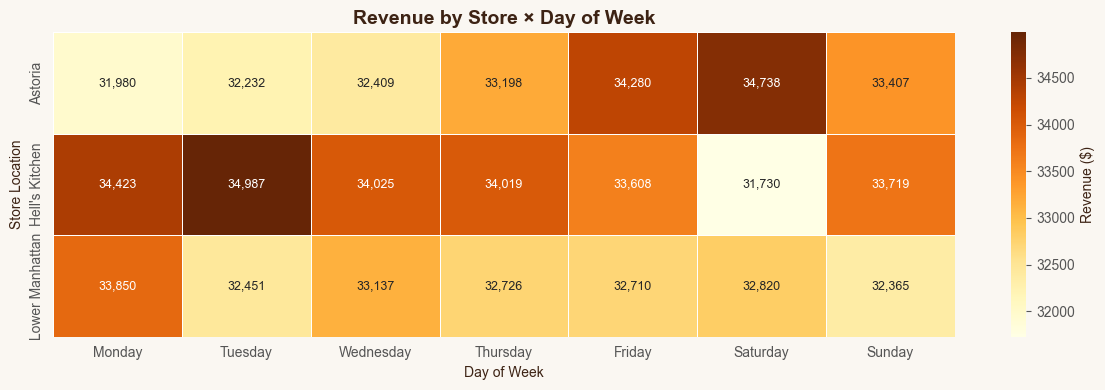

In [21]:
# ── Day-of-week revenue heatmap ───────────────────────────────────────────────
DOW_ORDER = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_store = df.groupby(['store_location','day_name'])['revenue'].sum().unstack(fill_value=0)
day_store = day_store.reindex(columns=[d for d in DOW_ORDER if d in day_store.columns])

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(day_store, ax=ax, cmap='YlOrBr', fmt=',.0f', annot=True,
            linewidths=0.5, linecolor='white', cbar_kws={'label': 'Revenue ($)'},
            annot_kws={'size': 9})
ax.set_title('Revenue by Store × Day of Week', fontsize=14, fontweight='bold', color=DARK_BROWN)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Store Location')
plt.tight_layout()
plt.show()

---
## 10. Key Insights & Recommendations <a id='10'></a>

In [22]:
# ── Summarize findings programmatically ───────────────────────────────────────
peak_h          = hourly.loc[hourly['Transactions'].idxmax(), 'hour']
peak_txn        = hourly.loc[hourly['Transactions'].idxmax(), 'Transactions']
peak_rev        = hourly.loc[hourly['Revenue'].idxmax(), 'Revenue']
morning_rev     = bucket_agg.loc[bucket_agg['time_bucket']=='Morning (6–11)', 'Revenue'].values[0]
morning_pct     = bucket_agg.loc[bucket_agg['time_bucket']=='Morning (6–11)', 'Rev_Share_%'].values[0]
top_store       = store_summary['Total_Revenue'].idxmax()
top_store_rev   = store_summary['Total_Revenue'].max()
top_cat         = cat_rev.idxmax()
top_cat_rev     = cat_rev.max()
top_cat_pct     = top_cat_rev / df['revenue'].sum() * 100

print('=' * 55)
print('   ☕ AFFICIONADO COFFEE — KEY ANALYTICAL FINDINGS')
print('=' * 55)
print(f'\n🕐 DEMAND PATTERNS')
print(f'   Peak Hour        : {peak_h}:00 AM')
print(f'   Peak Transactions: {peak_txn:,} in a single hour')
print(f'   Peak Revenue     : ${peak_rev:,.0f} in a single hour')
print(f'   Morning (6–11)   : ${morning_rev:,.0f} = {morning_pct}% of daily revenue')
print(f'\n🏪 STORE PERFORMANCE')
for store in store_summary.index:
    rev  = store_summary.loc[store, 'Total_Revenue']
    txn  = store_summary.loc[store, 'Transactions']
    avg  = store_summary.loc[store, 'Avg_Transaction']
    sh   = store_summary.loc[store, 'Revenue_Share_%']
    print(f'   {store:<18}: ${rev:>10,.0f} | {txn:>7,} txns | Avg ${avg:.2f} | {sh:.1f}%')
print(f'\n🛍️  PRODUCT PERFORMANCE')
print(f'   Top Category     : {top_cat} (${top_cat_rev:,.0f} | {top_cat_pct:.1f}% of revenue)')
print(f'   Top Product      : {top10.index[0]} (${top10.iloc[0]:,.0f})')
print(f'\n📋 STAFFING RECOMMENDATIONS')
print(f'   MAX staff        : 7:00 AM – 11:00 AM  (morning rush)')
print(f'   MED staff        : 11:00 AM – 5:00 PM  (afternoon plateau)')
print(f'   MIN staff        : 5:00 PM – 8:00 PM   (evening wind-down)')
print(f'   Review closing   : 8 PM hour = only 0.4% of daily revenue')
print('=' * 55)

   ☕ AFFICIONADO COFFEE — KEY ANALYTICAL FINDINGS

🕐 DEMAND PATTERNS
   Peak Hour        : 10:00 AM
   Peak Transactions: 18,545 in a single hour
   Peak Revenue     : $88,673 in a single hour
   Morning (6–11)   : $388,289 = 55.6% of daily revenue

🏪 STORE PERFORMANCE
   Astoria           : $   232,244 |  50,599 txns | Avg $4.59 | 33.2%
   Hell's Kitchen    : $   236,511 |  50,735 txns | Avg $4.66 | 33.8%
   Lower Manhattan   : $   230,057 |  47,782 txns | Avg $4.81 | 32.9%

🛍️  PRODUCT PERFORMANCE
   Top Category     : Coffee ($269,952 | 38.6% of revenue)
   Top Product      : Sustainably Grown Organic Lg ($21,152)

📋 STAFFING RECOMMENDATIONS
   MAX staff        : 7:00 AM – 11:00 AM  (morning rush)
   MED staff        : 11:00 AM – 5:00 PM  (afternoon plateau)
   MIN staff        : 5:00 PM – 8:00 PM   (evening wind-down)
   Review closing   : 8 PM hour = only 0.4% of daily revenue


---

### 📝 Summary of Recommendations

| Area | Recommendation |
|------|----------------|
| **Staffing** | Maximum crew 7–11 AM; reduce after 5 PM |
| **Inventory** | Pre-stock coffee & bakery by 6:30 AM |
| **Promotions** | Loyalty rewards at 6–7 AM to smooth demand curve |
| **Promotions** | Afternoon deals (2–5 PM) to boost the plateau |
| **Operations** | Review necessity of staying open past 7:30 PM |
| **Lower Manhattan** | Earlier close (7 PM) viable — sharp post-5 PM drop |

---
*Analysis completed — Afficionado Coffee Roasters | FY 2025 | 149,116 transactions*